In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


In [2]:
#Importing Libraries

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
data=pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.shape

(768, 9)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
#Check if there are any null values

In [8]:
data.isnull().values.any()

False

In [9]:
#check if there are any data duplicates

In [10]:
data.duplicated().any()

False

In [11]:
#Find the correlation amongst parameters

In [12]:
import seaborn as sns

In [13]:
correl = data.corr()

In [14]:
corr_features=correl.index

<AxesSubplot:>

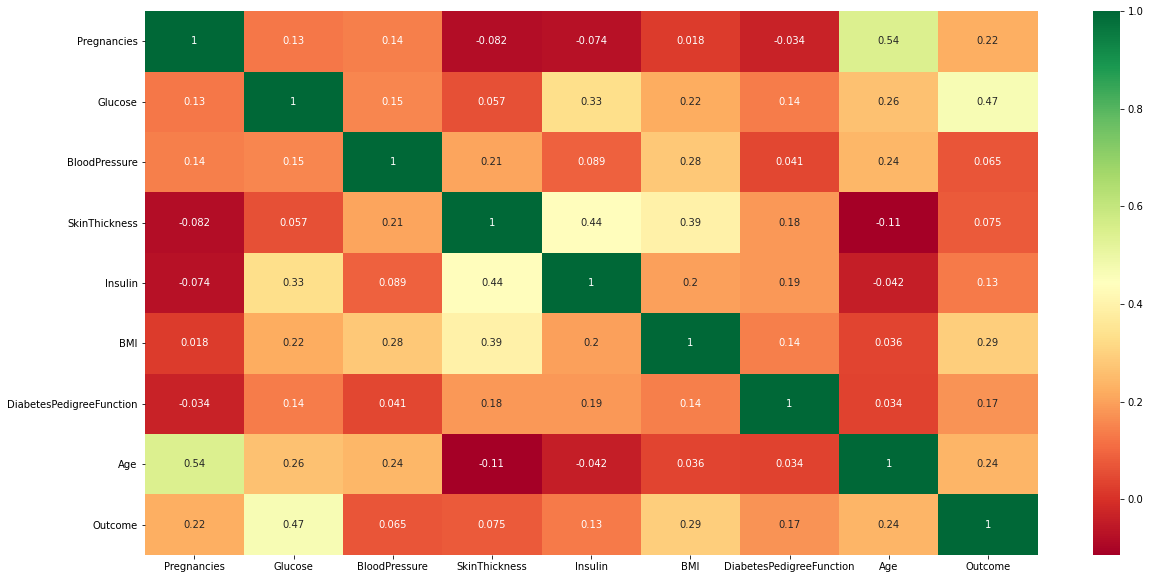

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn')

In [16]:
diabetic_check=data['Outcome'].value_counts().reset_index()
diabetic_check

,index,Outcome
0,0,500
1,1,268


In [17]:
diabetic = diabetic_check['Outcome'][1]
diabetic

268

In [18]:
non_diabetic = diabetic_check['Outcome'][0]
non_diabetic

500

In [19]:
(diabetic,non_diabetic)

(268, 500)

#Split in train and test set

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [22]:
feature_columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']
predicted_class=['Outcome']


In [23]:
X= data[feature_columns]
Y= data[predicted_class]

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,random_state=10)

In [25]:
len(X_train)

537

#Check for missing (zero) values

In [26]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [27]:
print("total number of rows : {0}".format(len(data)))
print("total number of rows missing in 'Pregnancies': {0}".format(sum(data['Pregnancies']==0)))
print("total number of rows missing in 'Glucose': {0}".format(sum(data['Glucose']==0)))
print("total number of rows missing in 'BloodPressure': {0}".format(sum(data['BloodPressure']==0)))
print("total number of rows missing in 'SkinThickness': {0}".format(sum(data['SkinThickness']==0)))
print("total number of rows missing in 'Insulin: {0}".format(sum(data['Insulin']==0)))
print("total number of rows missing in 'BMI': {0}".format(sum(data['BMI']==0)))
print("total number of rows missing in 'DiabetesPedigreeFunction': {0}".format(sum(data['DiabetesPedigreeFunction']==0)))
print("total number of rows missing in 'Age': {0}".format(sum(data['Age']==0)))

total number of rows : 768
total number of rows missing in 'Pregnancies': 111
total number of rows missing in 'Glucose': 5
total number of rows missing in 'BloodPressure': 35
total number of rows missing in 'SkinThickness': 227
total number of rows missing in 'Insulin: 374
total number of rows missing in 'BMI': 11
total number of rows missing in 'DiabetesPedigreeFunction': 0
total number of rows missing in 'Age': 0


In [28]:
from sklearn.impute import SimpleImputer
fill_values = SimpleImputer(missing_values=0, strategy='mean')

In [29]:
X_train = fill_values.fit_transform(X_train)
X_test = fill_values.fit_transform(X_test)

#Applying Algorithm

In [30]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model= RandomForestClassifier(random_state=10)
random_forest_model.fit(X_train,Y_train)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


RandomForestClassifier(random_state=10)